# Trend Prediction Analysis

This notebook builds a detailed trend-analysis workflow for crypto candles.

It answers five questions:
1. How to calculate trend as a signed percentage.
2. Which variables are most useful.
3. Which combinations of variables work best.
4. How much predictive accuracy indicator and pattern combinations can reach.
5. Which variables or combos are strongest for predicting future trend direction.

The notebook uses processed PostgreSQL candlestick tables and evaluates feature groups with time-aware validation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Ensure project root is on sys.path so app.* imports work in notebooks.
cwd = Path.cwd().resolve()
project_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "app" / "config" / "database.py").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError("Could not locate project root containing app/config/database.py")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from app.config.database import engine
from app.services.data_storage_service import DataStorageService

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

SYMBOL = "btcusdt"
INTERVAL = "4h"
HORIZON_BARS = 1
NEUTRAL_BAND_PCT = 0.25
TEST_SPLITS = 3

raw_table = DataStorageService.build_raw_table_name(SYMBOL, INTERVAL)
processed_table = DataStorageService.build_processed_table_name(SYMBOL, INTERVAL)
print(f"Symbol: {SYMBOL.upper()} | Interval: {INTERVAL}")
print(f"Raw table: {raw_table}")
print(f"Processed table: {processed_table}")
print(f"Prediction horizon: {HORIZON_BARS} bar(s)")
print(f"Neutral band: +/-{NEUTRAL_BAND_PCT:.2f}%")


def safe_read_sql(query: str, params: dict | None = None) -> pd.DataFrame:
    with engine.begin() as conn:
        return pd.read_sql(text(query), conn, params=params)


def load_processed_table(table_name: str) -> pd.DataFrame:
    df = safe_read_sql(f"SELECT * FROM {table_name} ORDER BY open_time_ms ASC")
    if df.empty:
        return df

    if "open_time" in df.columns:
        df["open_time"] = pd.to_datetime(df["open_time"], utc=True, errors="coerce")
    if "close_time" in df.columns:
        df["close_time"] = pd.to_datetime(df["close_time"], utc=True, errors="coerce")
    if "open_time_ms" in df.columns:
        df["open_time_utc"] = pd.to_datetime(df["open_time_ms"], unit="ms", utc=True, errors="coerce")
    return df


processed_df = load_processed_table(processed_table)
if processed_df.empty:
    raise RuntimeError(f"No rows found in {processed_table}. Run the collector and trend pipeline first.")

print(f"Loaded rows: {len(processed_df):,}")
processed_df.head(3)

Symbol: BTCUSDT | Interval: 4h
Raw table: btcusdt_4h_raw
Processed table: btcusdt_4h_processed
Prediction horizon: 1 bar(s)
Neutral band: +/-0.25%
Loaded rows: 18,910


,id,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore_value,open_time_ms,close_time_ms,is_synthetic,is_missing,is_interpolated,fill_source,fill_method,confidence_score,created_at,updated_at,ma_20,ema_12,ema_26,macd,macd_signal,macd_hist,adx_14,rsi_14,stoch_k_14,stoch_d_3,cci_20,bollinger_mid_20,bollinger_upper_20,bollinger_lower_20,atr_14,vix,obv,vwap,mfi_14,ad_line,volume_oscillator,candle_pattern_1,candle_pattern_2,candle_pattern_3,candle_pattern_complex,support,resistance,trend_pct_change,trend,trend_category,is_turning_point,turning_point_score,chart_pattern_type,chart_pattern_confidence,chart_pattern_direction,chart_pattern_start_time_ms,chart_pattern_end_time_ms,chart_pattern_key_points,open_time_utc
0,1,2017-08-17 04:00:00+00:00,4261.48,4349.99,4261.32,4349.99,82.088865,2017-08-17 07:59:59.999000+00:00,353194.332930,334,64.013727,275647.421911,0.0,1502942400000,1502956799999,False,False,False,raw_sync,raw_sync,1.0,2026-04-03 21:45:45.447858,2026-04-03 21:49:17.811528,4349.990000,4349.990000,4349.990000,0.000000,0.000000,0.000000,NaN,NaN,100.000000,100.000000,NaN,4349.990000,4349.99000,4349.990000,88.670000,NaN,0.000000,4320.433333,NaN,82.088865,0.000000,NaN,NaN,NaN,NaN,4261.32,4349.99,2.076978,sideaway,sideaway,False,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-17 04:00:00+00:00
1,2,2017-08-17 08:00:00+00:00,4333.32,4485.39,4333.32,4427.30,63.619882,2017-08-17 11:59:59.999000+00:00,282501.157750,248,58.787633,261054.051154,0.0,1502956800000,1502971199999,False,False,False,raw_sync,raw_sync,1.0,2026-04-03 21:45:45.447858,2026-04-03 21:49:17.811528,4388.645000,4361.883846,4355.716667,6.167179,1.233436,4.933744,100.0,NaN,74.075066,87.037533,133.333333,4388.645000,4465.95500,4311.335000,93.198571,NaN,63.619882,4361.870371,NaN,97.103776,-1.471021,NaN,NaN,NaN,NaN,4261.32,4485.39,2.168776,up,strong up,True,0.399444,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-17 08:00:00+00:00
2,3,2017-08-17 12:00:00+00:00,4436.06,4485.39,4333.42,4352.34,174.562001,2017-08-17 15:59:59.999000+00:00,774238.798317,858,125.184133,555419.758061,0.0,1502971200000,1502985599999,False,False,False,raw_sync,raw_sync,1.0,2026-04-03 21:45:45.447858,2026-04-03 21:49:17.811528,4376.543333,4360.415562,4355.466543,4.949019,1.976553,2.972466,100.0,93.059195,40.621234,71.565433,48.034445,4376.543333,4448.34974,4304.736926,97.396531,NaN,-110.942119,4377.411221,26.821725,-33.992895,5.733220,NaN,NaN,NaN,NaN,4261.32,4485.39,-1.887260,sideaway,sideaway,True,0.747949,Flag,0.72,bullish,1.502971e+12,1.503533e+12,"{""prior_slope"":77.30999999999949,""channel_slop...",2017-08-17 12:00:00+00:00


In [2]:
def signed_pct_change(series_a: pd.Series, series_b: pd.Series) -> pd.Series:
    base = pd.to_numeric(series_a, errors="coerce").replace(0, np.nan)
    compare = pd.to_numeric(series_b, errors="coerce")
    return ((compare - base) / base) * 100.0


def build_analysis_frame(df: pd.DataFrame, horizon_bars: int, neutral_band_pct: float) -> pd.DataFrame:
    out = df.copy().sort_values("open_time_ms").reset_index(drop=True)

    # Core trend score for the current candle.
    out["trend_score_pct"] = signed_pct_change(out["open"], out["close"])
    out["trend_direction"] = np.where(out["trend_score_pct"] > 0, 1, np.where(out["trend_score_pct"] < 0, -1, 0))

    # Prediction target: future signed percentage change over the next horizon.
    out["future_close"] = out["close"].shift(-horizon_bars)
    out["future_trend_score_pct"] = signed_pct_change(out["close"], out["future_close"])
    out["future_trend_direction"] = np.select(
        [out["future_trend_score_pct"] > neutral_band_pct, out["future_trend_score_pct"] < -neutral_band_pct],
        [1, -1],
        default=0,
    )

    # Simple derived variables that often help trend prediction.
    out["body_pct"] = signed_pct_change(out["open"], out["close"])
    out["range_pct"] = signed_pct_change(out["low"], out["high"])
    out["upper_wick_pct"] = ((pd.to_numeric(out["high"], errors="coerce") - pd.to_numeric(out["close"], errors="coerce")) / pd.to_numeric(out["close"], errors="coerce").replace(0, np.nan)) * 100.0
    out["lower_wick_pct"] = ((pd.to_numeric(out["open"], errors="coerce") - pd.to_numeric(out["low"], errors="coerce")) / pd.to_numeric(out["open"], errors="coerce").replace(0, np.nan)) * 100.0
    out["close_to_ema12_pct"] = signed_pct_change(out["ema_12"], out["close"]) if "ema_12" in out.columns else np.nan
    out["ema12_to_ema26_pct"] = signed_pct_change(out["ema_26"], out["ema_12"]) if {"ema_12", "ema_26"}.issubset(out.columns) else np.nan
    out["macd_strength"] = out["macd_hist"] if "macd_hist" in out.columns else np.nan
    out["volume_z_64"] = (pd.to_numeric(out["volume"], errors="coerce") - pd.to_numeric(out["volume"], errors="coerce").rolling(64, min_periods=8).mean()) / pd.to_numeric(out["volume"], errors="coerce").rolling(64, min_periods=8).std()

    if {"support", "resistance", "close"}.issubset(out.columns):
        out["support_distance_pct"] = signed_pct_change(out["support"], out["close"])
        out["resistance_distance_pct"] = signed_pct_change(out["close"], out["resistance"])

    if {"turning_point_score"}.issubset(out.columns):
        out["turning_point_score"] = pd.to_numeric(out["turning_point_score"], errors="coerce")
    else:
        out["turning_point_score"] = np.nan

    # Pattern flags. Use one-hot groups if categorical columns exist.
    pattern_cols = [c for c in out.columns if c.startswith("candle_pattern_")]
    for col in pattern_cols:
        out[col] = out[col].fillna("None").astype(str)

    # Drop rows without a future target.
    out = out.dropna(subset=["future_trend_score_pct"]).reset_index(drop=True)
    return out


analysis_df = build_analysis_frame(processed_df, HORIZON_BARS, NEUTRAL_BAND_PCT)
print(f"Analysis rows: {len(analysis_df):,}")
print("Current trend score and future target preview:")
display(analysis_df[[c for c in ["open_time_utc", "open", "close", "trend_score_pct", "future_trend_score_pct", "future_trend_direction"] if c in analysis_df.columns]].head(10))

Analysis rows: 18,901
Current trend score and future target preview:


,open_time_utc,open,close,trend_score_pct,future_trend_score_pct,future_trend_direction
0,2017-08-17 04:00:00+00:00,4261.48,4349.99,2.076978,1.777245,1
1,2017-08-17 08:00:00+00:00,4333.32,4427.30,2.168776,-1.693131,-1
2,2017-08-17 12:00:00+00:00,4436.06,4352.34,-1.887260,-0.622883,-1
3,2017-08-17 16:00:00+00:00,4352.33,4325.23,-0.622655,-0.928274,-1
4,2017-08-17 20:00:00+00:00,4307.56,4285.08,-0.521873,0.170592,0
5,2017-08-18 00:00:00+00:00,4285.08,4292.39,0.170592,0.183115,0
6,2017-08-18 04:00:00+00:00,4292.39,4300.25,0.183115,0.931574,1
7,2017-08-18 08:00:00+00:00,4285.00,4340.31,1.290782,-2.382779,-1
8,2017-08-18 12:00:00+00:00,4320.52,4236.89,-1.935647,-2.374619,-1
9,2017-08-18 16:00:00+00:00,4234.54,4136.28,-2.320441,-0.674761,-1


In [3]:
MAX_EVAL_ROWS = 60_000

# Keep the evaluation manageable while preserving time order.
if len(analysis_df) > MAX_EVAL_ROWS:
    step = max(1, len(analysis_df) // MAX_EVAL_ROWS)
    eval_df = analysis_df.iloc[::step].copy().reset_index(drop=True)
else:
    eval_df = analysis_df.copy().reset_index(drop=True)

numeric_feature_candidates = [
    "trend_score_pct",
    "body_pct",
    "range_pct",
    "upper_wick_pct",
    "lower_wick_pct",
    "close_to_ema12_pct",
    "ema12_to_ema26_pct",
    "ema_12",
    "ema_26",
    "adx_14",
    "rsi_14",
    "stoch_k_14",
    "stoch_d_3",
    "cci_20",
    "atr_14",
    "vix",
    "obv",
    "vwap",
    "mfi_14",
    "ad_line",
    "volume_oscillator",
    "macd",
    "macd_signal",
    "macd_hist",
    "support_distance_pct",
    "resistance_distance_pct",
    "turning_point_score",
    "is_turning_point",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
]

pattern_text_cols = [c for c in ["candle_pattern_1", "candle_pattern_2", "candle_pattern_3", "candle_pattern_complex"] if c in eval_df.columns]
available_numeric_features = [c for c in numeric_feature_candidates if c in eval_df.columns]

feature_groups = {
    "price_action": [c for c in ["trend_score_pct", "body_pct", "range_pct", "upper_wick_pct", "lower_wick_pct", "volume", "number_of_trades"] if c in eval_df.columns],
    "indicators": [c for c in ["close_to_ema12_pct", "ema12_to_ema26_pct", "ema_12", "ema_26", "adx_14", "rsi_14", "stoch_k_14", "stoch_d_3", "cci_20", "atr_14", "vix", "obv", "vwap", "mfi_14", "ad_line", "volume_oscillator", "macd", "macd_signal", "macd_hist"] if c in eval_df.columns],
    "support_turning": [c for c in ["support_distance_pct", "resistance_distance_pct", "turning_point_score", "is_turning_point"] if c in eval_df.columns],
    "patterns": pattern_text_cols + [c for c in ["is_turning_point", "turning_point_score"] if c in eval_df.columns],
    "price_plus_indicators": [c for c in ["trend_score_pct", "body_pct", "range_pct", "upper_wick_pct", "lower_wick_pct", "volume", "number_of_trades", "close_to_ema12_pct", "ema12_to_ema26_pct", "ema_12", "ema_26", "adx_14", "rsi_14", "stoch_k_14", "stoch_d_3", "cci_20", "atr_14", "vix", "obv", "vwap", "mfi_14", "ad_line", "volume_oscillator", "macd", "macd_signal", "macd_hist"] if c in eval_df.columns],
    "indicators_plus_patterns": [c for c in ["close_to_ema12_pct", "ema12_to_ema26_pct", "ema_12", "ema_26", "adx_14", "rsi_14", "stoch_k_14", "stoch_d_3", "cci_20", "atr_14", "vix", "obv", "vwap", "mfi_14", "ad_line", "volume_oscillator", "macd", "macd_signal", "macd_hist", "support_distance_pct", "resistance_distance_pct", "turning_point_score", "is_turning_point"] if c in eval_df.columns] + pattern_text_cols,
    "all_features": available_numeric_features + pattern_text_cols,
}

# Remove duplicates while preserving order.
for group_name, cols in feature_groups.items():
    seen = set()
    cleaned = []
    for col in cols:
        if col not in seen:
            cleaned.append(col)
            seen.add(col)
    feature_groups[group_name] = cleaned


def make_xy(df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    frame = df.copy()
    categorical_cols = [c for c in feature_cols if c in pattern_text_cols]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    X = frame[numeric_cols].copy()
    if categorical_cols:
        pattern_frame = pd.get_dummies(frame[categorical_cols], columns=categorical_cols, dummy_na=True, prefix_sep="__")
        X = pd.concat([X, pattern_frame], axis=1)

    y = frame["future_trend_direction"].astype(int)
    mask = y.notna()
    X = X.loc[mask].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True)
    return X, y


def evaluate_group(df: pd.DataFrame, feature_cols: list[str], model_name: str = "logistic") -> dict:
    X, y = make_xy(df, feature_cols)
    if len(X) < 500:
        return {
            "rows": len(X),
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_macro": np.nan,
            "directional_accuracy": np.nan,
        }

    tscv = TimeSeriesSplit(n_splits=TEST_SPLITS)
    metrics = []

    if model_name == "logistic":
        estimator = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        max_iter=2000,
                        solver="lbfgs",
                        class_weight="balanced",
                    ),
                ),
            ]
        )
    elif model_name == "forest":
        estimator = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=80,
                        max_depth=8,
                        min_samples_leaf=30,
                        class_weight="balanced_subsample",
                        n_jobs=-1,
                        random_state=42,
                    ),
                ),
            ]
        )
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)

        metrics.append(
            {
                "accuracy": accuracy_score(y_test, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                "f1_macro": f1_score(y_test, y_pred, average="macro"),
                "directional_accuracy": accuracy_score(y_test, y_pred),
            }
        )

    summary = pd.DataFrame(metrics).mean(numeric_only=True).to_dict()
    summary["rows"] = len(X)
    return summary


results = []
for group_name, cols in feature_groups.items():
    logistic_result = evaluate_group(eval_df, cols, model_name="logistic")
    forest_result = evaluate_group(eval_df, cols, model_name="forest")
    results.append(
        {
            "feature_group": group_name,
            "model": "logistic",
            **logistic_result,
        }
    )
    results.append(
        {
            "feature_group": group_name,
            "model": "forest",
            **forest_result,
        }
    )

results_df = pd.DataFrame(results).sort_values(["balanced_accuracy", "f1_macro"], ascending=False)
display(results_df)

best_row = results_df.iloc[0]
print(
    f"Best combo so far: {best_row['feature_group']} with {best_row['model']} | "
    f"balanced_accuracy={best_row['balanced_accuracy']:.4f}, f1_macro={best_row['f1_macro']:.4f}, accuracy={best_row['accuracy']:.4f}"
)

results_df

,feature_group,model,accuracy,balanced_accuracy,f1_macro,directional_accuracy,rows
13,all_features,forest,0.420882,0.427904,0.402742,0.420882,18901
9,price_plus_indicators,forest,0.408113,0.416215,0.386075,0.408113,18901
5,support_turning,forest,0.411711,0.414667,0.399868,0.411711,18901
1,price_action,forest,0.407266,0.412606,0.401876,0.407266,18901
11,indicators_plus_patterns,forest,0.396473,0.403554,0.372298,0.396473,18901
0,price_action,logistic,0.387513,0.401363,0.356286,0.387513,18901
8,price_plus_indicators,logistic,0.387302,0.395177,0.357913,0.387302,18901
10,indicators_plus_patterns,logistic,0.382646,0.393489,0.349195,0.382646,18901
12,all_features,logistic,0.384409,0.392082,0.359835,0.384409,18901
2,indicators,logistic,0.383492,0.391239,0.346743,0.383492,18901


Best combo so far: all_features with forest | balanced_accuracy=0.4279, f1_macro=0.4027, accuracy=0.4209


,feature_group,model,accuracy,balanced_accuracy,f1_macro,directional_accuracy,rows
13,all_features,forest,0.420882,0.427904,0.402742,0.420882,18901
9,price_plus_indicators,forest,0.408113,0.416215,0.386075,0.408113,18901
5,support_turning,forest,0.411711,0.414667,0.399868,0.411711,18901
1,price_action,forest,0.407266,0.412606,0.401876,0.407266,18901
11,indicators_plus_patterns,forest,0.396473,0.403554,0.372298,0.396473,18901
0,price_action,logistic,0.387513,0.401363,0.356286,0.387513,18901
8,price_plus_indicators,logistic,0.387302,0.395177,0.357913,0.387302,18901
10,indicators_plus_patterns,logistic,0.382646,0.393489,0.349195,0.382646,18901
12,all_features,logistic,0.384409,0.392082,0.359835,0.384409,18901
2,indicators,logistic,0.383492,0.391239,0.346743,0.383492,18901


## Trend Interpretation and Feature Ranking

This section identifies the strongest variables and feature combinations for predicting future trend direction.

- The target is `future_trend_direction`.
- `future_trend_score_pct` is the signed percentage move over the selected horizon.
- Higher positive scores mean bullish follow-through.
- Lower negative scores mean bearish follow-through.
- The best feature group is the one with the highest balanced accuracy and macro F1, because those metrics are less sensitive to class imbalance than plain accuracy.

,future_trend_direction,count,mean,median,min,max
0,-1,6497,-1.222254,-0.792116,-20.496236,-0.250101
1,0,5396,0.001772,0.000142,-0.249864,0.249842
2,1,7008,1.199375,0.793238,0.250062,31.209318


,feature,mutual_info
19,ad_line,0.043825
15,vix,0.032940
2,range_pct,0.029221
7,ema_12,0.024746
17,vwap,0.024368
6,ema12_to_ema26_pct,0.023326
8,ema_26,0.023064
1,body_pct,0.019905
0,trend_score_pct,0.019900
16,obv,0.018468


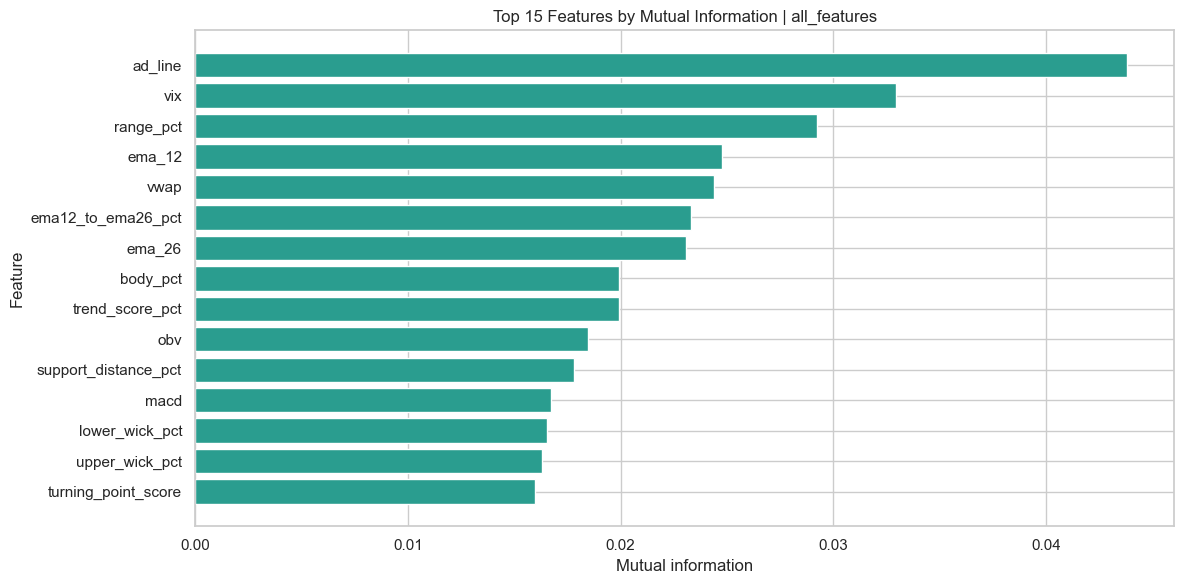

,pred_down,pred_flat,pred_up
actual_down,641,597,335
actual_flat,361,832,236
actual_up,512,664,547


Best feature group: all_features
Best model: forest
Best accuracy: 0.4209
Best balanced accuracy: 0.4279
Best macro F1: 0.4027


In [4]:
best_group_name = str(best_row["feature_group"])
best_group_cols = feature_groups[best_group_name]
X_best, y_best = make_xy(eval_df, best_group_cols)

imputer = SimpleImputer(strategy="median")
X_best_imputed = imputer.fit_transform(X_best)
feature_names = list(X_best.columns)

mi_scores = mutual_info_classif(X_best_imputed, y_best, random_state=42)
mi_df = pd.DataFrame({
    "feature": feature_names,
    "mutual_info": mi_scores,
}).sort_values("mutual_info", ascending=False)

# Simple directional summary of the future target.
target_summary = analysis_df.groupby("future_trend_direction")["future_trend_score_pct"].agg(["count", "mean", "median", "min", "max"]).reset_index()

display(target_summary)
display(mi_df.head(20))

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = mi_df.head(15).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["mutual_info"], color="#2a9d8f")
ax.set_title(f"Top 15 Features by Mutual Information | {best_group_name}")
ax.set_xlabel("Mutual information")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

# Confusion matrix for the best combo and model.
X_best_eval, y_best_eval = X_best.copy(), y_best.copy()
if best_row["model"] == "logistic":
    best_estimator = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")),
        ]
    )
else:
    best_estimator = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=150,
                max_depth=10,
                min_samples_leaf=20,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=42,
            )),
        ]
    )

splitter = TimeSeriesSplit(n_splits=TEST_SPLITS)
last_train_idx, last_test_idx = list(splitter.split(X_best_eval))[-1]
X_train, X_test = X_best_eval.iloc[last_train_idx], X_best_eval.iloc[last_test_idx]
y_train, y_test = y_best_eval.iloc[last_train_idx], y_best_eval.iloc[last_test_idx]
best_estimator.fit(X_train, y_train)
y_pred = best_estimator.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
cm_df = pd.DataFrame(cm, index=["actual_down", "actual_flat", "actual_up"], columns=["pred_down", "pred_flat", "pred_up"])
display(cm_df)

print("Best feature group:", best_group_name)
print("Best model:", best_row["model"])
print("Best accuracy:", round(float(best_row["accuracy"]), 4))
print("Best balanced accuracy:", round(float(best_row["balanced_accuracy"]), 4))
print("Best macro F1:", round(float(best_row["f1_macro"]), 4))